# Notebook 10: SASRec DCN-v2 Re-Ranker

## Purpose

This notebook trains a **DCN-v2 re-ranker on SASRec sequential embeddings** (105 dimensions). SASRec captures temporal dynamics in user behavior via self-attention over the interaction sequence, producing embeddings that reflect the user's *current* interests rather than static lifetime preferences.

The key question: **can DCN-v2's explicit feature interactions compensate for SASRec's lower Recall@200 (0.22 vs Two-Tower's 0.27)?** If SASRec retrieves more contextually relevant candidates (recent interests), the ranker may produce better final top-10 despite fewer total positives in the candidate pool.

## Feature vector (105 dimensions)

Same structure as Two-Tower (Notebook 04):
| Component | Dims | Description |
|-----------|------|-------------|
| retrieval_score | 1 | dot(SASRec user embedding, item embedding) |
| user_features | 24 | Activity level, genre preferences, rating behavior |
| item_features | 73 | Genres, popularity, year, genome PCA |
| cross_features | 7 | Genre match, popularity gap, temporal signals |

## What we produce

| Output | Description |
|--------|-------------|
| `models/sasrec/dcn_v2_ranker.pt` | Trained DCN-v2 state dict |
| `models/sasrec/dcn_v2_config.json` | Architecture config |
| `models/sasrec/dcn_v2_training_history.pkl` | Per-epoch metrics |

## Section 1: Load Embeddings and Features

In [1]:
import numpy as np
import pandas as pd
import pickle
import time
import json
import gc
import os
from pathlib import Path
from typing import List, Tuple

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import OneCycleLR

import xgboost as xgb
from sklearn.metrics import roc_auc_score
from scipy import stats
from scipy.stats import false_discovery_control
import matplotlib.pyplot as plt

DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models/sasrec')

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

n_users = metadata['n_users']
n_movies = metadata['n_movies']
user2idx = metadata['user2idx']
movie2idx = metadata['movie2idx']
idx2user = metadata['idx2user']
idx2movie = metadata['idx2movie']

user_embeddings = np.load(MODEL_DIR / 'user_embeddings.npy')
item_embeddings = np.load(MODEL_DIR / 'item_embeddings.npy')

user_features_df = pd.read_parquet(DATA_DIR / 'user_features.parquet')
item_features_df = pd.read_parquet(DATA_DIR / 'item_features.parquet')
user_feat_cols = user_features_df.columns.tolist()
item_feat_cols = item_features_df.columns.tolist()

user_feat_matrix = np.zeros((n_users, len(user_feat_cols)), dtype=np.float32)
for uid, uidx in user2idx.items():
    if uid in user_features_df.index:
        user_feat_matrix[uidx] = user_features_df.loc[uid].values

item_feat_matrix = np.zeros((n_movies, len(item_feat_cols)), dtype=np.float32)
for mid, midx in movie2idx.items():
    if mid in item_features_df.index:
        item_feat_matrix[midx] = item_features_df.loc[mid].values

del user_features_df, item_features_df
gc.collect()

print(f'User embeddings: {user_embeddings.shape}')
print(f'Item embeddings: {item_embeddings.shape}')
print(f'User features: {user_feat_matrix.shape}')
print(f'Item features: {item_feat_matrix.shape}')

Device: mps


User embeddings: (138002, 128)
Item embeddings: (21082, 128)
User features: (138002, 24)
Item features: (21082, 73)


## Section 2: Build Feature Matrix (105 dimensions)

Same structure as Two-Tower Notebook 04: a single retrieval_score (dot product between SASRec user embedding and item embedding) plus user/item/cross features.

In [2]:
train_df = pd.read_parquet(DATA_DIR / 'train_set.parquet')
val_df = pd.read_parquet(DATA_DIR / 'val_set.parquet')
test_df = pd.read_parquet(DATA_DIR / 'test_set.parquet')

train_interaction_feats = pd.read_parquet(DATA_DIR / 'train_interaction_features.parquet')
val_interaction_feats = pd.read_parquet(DATA_DIR / 'val_interaction_features.parquet')
test_interaction_feats = pd.read_parquet(DATA_DIR / 'test_interaction_features.parquet')

valid_val_mask = val_df['user_idx'] > 0
val_df = val_df[valid_val_mask].reset_index(drop=True)
val_interaction_feats = val_interaction_feats[valid_val_mask].reset_index(drop=True)

valid_test_mask = test_df['user_idx'] > 0
test_df = test_df[valid_test_mask].reset_index(drop=True)
test_interaction_feats = test_interaction_feats[valid_test_mask].reset_index(drop=True)

print(f'Train: {len(train_df):,} interactions ({train_df["user_idx"].nunique():,} users)')
print(f'Val: {len(val_df):,} interactions ({val_df["user_idx"].nunique():,} users)')
print(f'Test: {len(test_df):,} interactions ({test_df["user_idx"].nunique():,} users)')

Train: 20,001,833 interactions (138,001 users)
Val: 355,378 interactions (5,191 users)
Test: 228,448 interactions (4,005 users)


### Define Feature Schema and Build Feature Construction Pipeline

**Why this step exists:** The raw data (embeddings, user features, item features, interaction features) lives in separate arrays and DataFrames. Before we can train any model, we need a deterministic function that assembles these disparate sources into a single fixed-width feature vector for each (user, item) pair. This cell defines that assembly logic and also performs training set subsampling to keep memory and compute manageable.

**What the code does:**

1. **Feature name registry** -- Defines the ordered list of 105 feature names (1 retrieval score + 24 user features + 73 item features + 7 cross/interaction features). This registry ensures consistent column ordering between training, validation, and test matrices and is later saved into the model config for reproducibility.

2. **`build_features_chunked` function** -- Constructs the full feature matrix in memory-friendly chunks (500K rows at a time). For each chunk it computes the dot-product retrieval score between SASRec user and item embeddings, concatenates the pre-computed user feature vector, the item feature vector, and the 7 cross-features (genre match, popularity gap, movie age at rating, and cyclical time encodings for day-of-week and hour).

3. **Training subsampling** -- Rather than training on all 20M interactions (which would be slow and memory-intensive), we sample approximately 3M interactions by selecting whole users at random until we reach the target size. Sampling by user (rather than by row) preserves the full interaction history for each selected user, which is critical for ranking metrics that are computed per-user.

4. **Validation and test preparation** -- Extracts the user/item index arrays and label arrays for val and test sets, then frees the original DataFrames to reclaim memory.

**What to expect:** A print confirming 105 total features, followed by the subsampled training size (approximately 3M rows from around 20K users). Memory from the original DataFrames is freed via garbage collection.

In [3]:
feature_names = (
    ['retrieval_score'] +
    [f'user_{c}' for c in user_feat_cols] +
    [f'item_{c}' for c in item_feat_cols] +
    [f'cross_{c}' for c in ['genre_match_score', 'popularity_gap', 'movie_age_at_rating',
                             'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos']]
)
INPUT_DIM = len(feature_names)
print(f'Total features: {INPUT_DIM}')


def build_features_chunked(user_idxs, movie_idxs, cross_arr, chunk_size=500_000):
    n = len(user_idxs)
    n_features = 1 + len(user_feat_cols) + len(item_feat_cols) + 7
    features = np.empty((n, n_features), dtype=np.float32)

    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        u_idx = user_idxs[start:end]
        m_idx = movie_idxs[start:end]

        features[start:end, 0] = np.sum(
            user_embeddings[u_idx] * item_embeddings[m_idx], axis=1
        )
        features[start:end, 1:1+len(user_feat_cols)] = user_feat_matrix[u_idx]
        features[start:end, 1+len(user_feat_cols):1+len(user_feat_cols)+len(item_feat_cols)] = item_feat_matrix[m_idx]
        features[start:end, -7:] = cross_arr[start:end]

    return features


TRAIN_SAMPLE_SIZE = 3_000_000
np.random.seed(42)
user_groups = train_df.groupby('user_idx').size()
users_shuffled = user_groups.index.values.copy()
np.random.shuffle(users_shuffled)

cumulative = 0
selected_users = []
for u in users_shuffled:
    selected_users.append(u)
    cumulative += user_groups[u]
    if cumulative >= TRAIN_SAMPLE_SIZE:
        break

train_mask = train_df['user_idx'].isin(set(selected_users))
train_user_idxs = train_df.loc[train_mask, 'user_idx'].values.copy()
train_movie_idxs = train_df.loc[train_mask, 'movie_idx'].values.copy()
y_train = train_df.loc[train_mask, 'label'].values.astype(np.float32)
train_cross_arr = train_interaction_feats.loc[train_mask].values.astype(np.float32)
print(f'Subsampled training: {len(y_train):,} rows from {len(selected_users):,} users')

del train_df, train_interaction_feats
gc.collect()

val_user_idxs = val_df['user_idx'].values.copy()
val_movie_idxs = val_df['movie_idx'].values.copy()
y_val = val_df['label'].values.astype(np.float32)
val_cross_arr = val_interaction_feats.values.astype(np.float32)

test_user_idxs = test_df['user_idx'].values.copy()
test_movie_idxs = test_df['movie_idx'].values.copy()
y_test = test_df['label'].values.astype(np.float32)
test_cross_arr = test_interaction_feats.values.astype(np.float32)

del val_df, test_df, val_interaction_feats, test_interaction_feats
gc.collect()

Total features: 105


Subsampled training: 3,000,109 rows from 20,539 users


0

### Materialize Feature Matrices for Train, Validation, and Test

**Why this step exists:** The previous cell defined the feature construction function but did not actually build the matrices. We separate definition from execution because (a) it makes the pipeline easier to debug -- if something goes wrong during materialization we know it is a data issue rather than a logic issue, and (b) building large NumPy arrays is memory-intensive, so we want to free intermediate arrays (like `train_cross_arr`) as soon as each matrix is built.

**What the code does:**

Calls `build_features_chunked` three times -- once each for train, validation, and test splits -- producing dense float32 NumPy arrays of shape (N, 105). After each call, the temporary cross-feature array is deleted and garbage-collected to minimize peak memory usage. Finally, it prints the label distribution (fraction of positive labels) for each split to verify class balance.

**What to expect:** You will see the shape and memory footprint of X_train (approximately 1.26 GB for 3M rows x 105 features at float32), followed by X_val and X_test shapes. The label distributions should show roughly 58-61% positive labels across splits, reflecting the candidate generation strategy where retrieved items are more likely to be relevant than random negatives.

In [4]:
print('Building feature matrices...')
t0 = time.time()

X_train = build_features_chunked(train_user_idxs, train_movie_idxs, train_cross_arr)
del train_cross_arr
gc.collect()
print(f'  X_train: {X_train.shape}, {X_train.nbytes/1e9:.2f} GB, {time.time()-t0:.1f}s')

X_val = build_features_chunked(val_user_idxs, val_movie_idxs, val_cross_arr)
del val_cross_arr
gc.collect()
print(f'  X_val: {X_val.shape}')

X_test = build_features_chunked(test_user_idxs, test_movie_idxs, test_cross_arr)
del test_cross_arr
gc.collect()
print(f'  X_test: {X_test.shape}')

print(f'\nLabel distributions:')
print(f'  Train: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

Building feature matrices...


  X_train: (3000109, 105), 1.26 GB, 0.7s
  X_val: (355378, 105)
  X_test: (228448, 105)

Label distributions:


  Train: 0.613, Val: 0.597, Test: 0.582


## Section 3: DCN-v2 Model

In [5]:
class CrossLayer(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(input_dim, input_dim))
        self.bias = nn.Parameter(torch.zeros(input_dim))
        nn.init.xavier_normal_(self.weight)

    def forward(self, x_0: torch.Tensor, x_l: torch.Tensor) -> torch.Tensor:
        return x_0 * (F.linear(x_l, self.weight, self.bias)) + x_l


class CrossNetwork(nn.Module):
    def __init__(self, input_dim: int, n_layers: int):
        super().__init__()
        self.layers = nn.ModuleList([CrossLayer(input_dim) for _ in range(n_layers)])

    def forward(self, x_0: torch.Tensor) -> torch.Tensor:
        x_l = x_0
        for layer in self.layers:
            x_l = layer(x_0, x_l)
        return x_l


class DeepNetwork(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        self.mlp = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x)


class DCNv2(nn.Module):
    def __init__(self, input_dim: int, n_cross_layers: int = 3,
                 deep_hidden_dims: List[int] = None, dropout: float = 0.1):
        super().__init__()
        if deep_hidden_dims is None:
            deep_hidden_dims = [256, 128]
        self.cross_network = CrossNetwork(input_dim, n_cross_layers)
        self.deep_network = DeepNetwork(input_dim, deep_hidden_dims, dropout)
        combined_dim = input_dim + deep_hidden_dims[-1]
        self.output_layer = nn.Linear(combined_dim, 1)
        self.input_dim = input_dim
        self.n_cross_layers = n_cross_layers
        self.deep_hidden_dims = deep_hidden_dims
        self.dropout = dropout

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cross_out = self.cross_network(x)
        deep_out = self.deep_network(x)
        combined = torch.cat([cross_out, deep_out], dim=1)
        return self.output_layer(combined).squeeze(-1)

    def get_config(self) -> dict:
        return {
            'input_dim': self.input_dim,
            'n_cross_layers': self.n_cross_layers,
            'deep_hidden_dims': self.deep_hidden_dims,
            'dropout': self.dropout,
        }


N_CROSS_LAYERS = 3
DEEP_HIDDEN_DIMS = [256, 128]
DROPOUT = 0.1

model = DCNv2(
    input_dim=INPUT_DIM,
    n_cross_layers=N_CROSS_LAYERS,
    deep_hidden_dims=DEEP_HIDDEN_DIMS,
    dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'DCN-v2 Architecture (SASRec features):')
print(f'  Input dim: {INPUT_DIM}')
print(f'  Cross layers: {N_CROSS_LAYERS}, Deep: {INPUT_DIM} -> {" -> ".join(map(str, DEEP_HIDDEN_DIMS))}')
print(f'  Total parameters: {total_params:,}')

DCN-v2 Architecture (SASRec features):
  Input dim: 105
  Cross layers: 3, Deep: 105 -> 256 -> 128
  Total parameters: 94,424


## Section 4: Training

In [6]:
def compute_bpr_loss(scores, labels):
    pos_mask = labels == 1
    neg_mask = labels == 0
    if pos_mask.sum() == 0 or neg_mask.sum() == 0:
        return torch.tensor(0.0, device=scores.device)
    pos_scores = scores[pos_mask]
    neg_scores = scores[neg_mask]
    n_pairs = min(len(pos_scores), len(neg_scores))
    pos_sample = pos_scores[torch.randperm(len(pos_scores), device=scores.device)[:n_pairs]]
    neg_sample = neg_scores[torch.randperm(len(neg_scores), device=scores.device)[:n_pairs]]
    return -F.logsigmoid(pos_sample - neg_sample).mean()


def compute_ndcg_at_k(scores, labels, user_idxs, k=10, max_users=2000):
    sort_idx = np.argsort(user_idxs, kind='stable')
    scores_sorted = scores[sort_idx]
    labels_sorted = labels[sort_idx]
    users_sorted = user_idxs[sort_idx]
    unique_users, group_starts = np.unique(users_sorted, return_index=True)
    group_ends = np.append(group_starts[1:], len(users_sorted))
    ndcgs = []
    for i in range(min(len(unique_users), max_users)):
        start, end = group_starts[i], group_ends[i]
        if end - start < 2:
            continue
        group_scores = scores_sorted[start:end]
        group_labels = labels_sorted[start:end]
        if group_labels.sum() == 0:
            continue
        rank_order = np.argsort(group_scores)[::-1]
        ranked_labels = group_labels[rank_order]
        actual_k = min(k, len(ranked_labels))
        dcg = np.sum(ranked_labels[:actual_k] / np.log2(np.arange(2, actual_k + 2)))
        ideal = np.sort(group_labels)[::-1][:actual_k]
        idcg = np.sum(ideal / np.log2(np.arange(2, actual_k + 2)))
        if idcg > 0:
            ndcgs.append(dcg / idcg)
    return np.mean(ndcgs) if ndcgs else 0.0


BATCH_SIZE = 4096
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 30
PATIENCE = 5
BPR_ALPHA = 0.5
GRAD_CLIP_NORM = 1.0

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * MAX_EPOCHS
scheduler = OneCycleLR(optimizer, max_lr=LEARNING_RATE, total_steps=total_steps,
                       pct_start=0.1, anneal_strategy='cos')

print(f'Training: batch={BATCH_SIZE}, lr={LEARNING_RATE}, loss={BPR_ALPHA}*BCE+{1-BPR_ALPHA}*BPR')
print(f'Steps/epoch: {len(train_loader):,}, Max epochs: {MAX_EPOCHS}, Patience: {PATIENCE}')

Training: batch=4096, lr=0.001, loss=0.5*BCE+0.5*BPR
Steps/epoch: 733, Max epochs: 30, Patience: 5


### Execute the Training Loop

**Why this step exists:** With the model architecture defined and hyperparameters configured in the previous cell, we now run the actual optimization. This is the core learning step where the DCN-v2 model adjusts its cross-layer weights and deep network parameters to discriminate between positive and negative (user, item) pairs. Early stopping on validation NDCG@10 prevents overfitting -- the model checkpoint from the best epoch is saved and all subsequent epochs that fail to improve are counted toward the patience budget.

**What the code does:**

For each epoch (up to 30):
1. **Training pass** -- Iterates over mini-batches of 4096 samples, computing the combined loss (0.5 * BCE + 0.5 * BPR) and updating weights via AdamW with gradient clipping at norm 1.0. The OneCycleLR scheduler adjusts the learning rate after every batch (not every epoch), following a cosine annealing schedule with a 10% warmup phase.
2. **Validation pass** -- Scores the entire validation set in one forward pass (no gradients), then computes BCE loss, AUC, and per-user NDCG@10 to track ranking quality.
3. **Early stopping check** -- If validation NDCG@10 improves, the model state dict is saved to disk and the patience counter resets. Otherwise, patience decrements. After 5 consecutive epochs without improvement, training halts.

**What to expect:** A table with one row per epoch showing train loss, validation loss, validation AUC, validation NDCG@10, current learning rate, and wall-clock time. Train loss should drop quickly in the first few epochs (the initial high value reflects random initialization). Validation NDCG@10 should plateau around 0.87-0.88. Training will likely stop between epochs 20-30 due to early stopping.

In [7]:
print('Training DCN-v2 on SASRec features...')
print(f'{"Epoch":<8}{"Train Loss":<14}{"Val Loss":<12}{"Val AUC":<12}{"Val NDCG@10":<14}{"LR":<12}{"Time":<8}')
print('-' * 80)

history = []
best_val_ndcg = -1
best_epoch = -1
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    t_epoch = time.time()
    model.train()
    epoch_loss = 0.0
    n_batches = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        scores = model(batch_X)
        bce_loss = F.binary_cross_entropy_with_logits(scores, batch_y)
        bpr_loss = compute_bpr_loss(scores, batch_y)
        loss = BPR_ALPHA * bce_loss + (1 - BPR_ALPHA) * bpr_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / n_batches

    model.eval()
    with torch.no_grad():
        val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        val_scores = model(val_tensor).cpu().numpy()
        del val_tensor

    val_bce = float(F.binary_cross_entropy_with_logits(
        torch.tensor(val_scores), torch.tensor(y_val)).item())
    val_auc = roc_auc_score(y_val, val_scores)
    val_ndcg = compute_ndcg_at_k(val_scores, y_val, val_user_idxs, k=10)

    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - t_epoch

    history.append({
        'epoch': epoch + 1, 'train_loss': avg_loss, 'val_loss': val_bce,
        'val_auc': val_auc, 'val_ndcg_10': val_ndcg, 'lr': current_lr, 'time': epoch_time,
    })

    print(f'{epoch+1:<8}{avg_loss:<14.4f}{val_bce:<12.4f}{val_auc:<12.4f}{val_ndcg:<14.4f}{current_lr:<12.2e}{epoch_time:<8.1f}s')

    if val_ndcg > best_val_ndcg:
        best_val_ndcg = val_ndcg
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_DIR / 'dcn_v2_ranker.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}. Best: epoch {best_epoch} (NDCG@10={best_val_ndcg:.4f})')
            break

print(f'\nTraining complete. Best epoch: {best_epoch}, Best val NDCG@10: {best_val_ndcg:.4f}')

Training DCN-v2 on SASRec features...
Epoch   Train Loss    Val Loss    Val AUC     Val NDCG@10   LR          Time    
--------------------------------------------------------------------------------


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


1       8.4319        0.6406      0.7057      0.8209        2.80e-04    17.1    s


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


2       0.5208        0.5846      0.7562      0.8454        7.60e-04    14.9    s


...

24      0.4054        0.5981      0.7738      0.8754        1.17e-04    14.5    s


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


25      0.4050        0.5984      0.7740      0.8756        8.22e-05    14.7    s


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


26      0.4047        0.5988      0.7740      0.8769        5.32e-05    14.5    s

Early stopping at epoch 26. Best: epoch 21 (NDCG@10=0.8773)

Training complete. Best epoch: 21, Best val NDCG@10: 0.8773


### Save Model Artifacts and Training Configuration

**Why this step exists:** Reproducibility and deployment require more than just a model checkpoint. We persist the full training history (for later visualization or comparison) and a JSON config that records both the architecture (input_dim, number of cross layers, deep hidden dims, dropout) and training metadata (batch size, learning rate, best epoch, feature names, retrieval model identity). This config file is the single source of truth for recreating or loading this model in downstream notebooks (e.g., the evaluation pipeline in Notebook 11 or the production inference system in Notebook 12).

**What the code does:**

1. Pickles the `history` list (one dict per epoch with train_loss, val_loss, val_auc, val_ndcg_10, lr, time) to `dcn_v2_training_history.pkl`.
2. Extracts the model config via `model.get_config()`, augments it with training hyperparameters and metadata (including the explicit note that the retrieval model is SASRec), then writes it as formatted JSON to `dcn_v2_config.json`.
3. Prints the saved model file path and its size on disk to confirm the save succeeded.

**What to expect:** A confirmation line showing the path to the saved `.pt` file and its size (approximately 0.4 MB for a 94K-parameter model stored in float32).

In [8]:
with open(MODEL_DIR / 'dcn_v2_training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

config = model.get_config()
config['training'] = {
    'batch_size': BATCH_SIZE, 'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY, 'bpr_alpha': BPR_ALPHA,
    'best_epoch': best_epoch, 'best_val_ndcg_10': best_val_ndcg,
    'n_train_samples': len(X_train), 'feature_names': feature_names,
    'retrieval_model': 'SASRec (self-attention sequential)',
}

with open(MODEL_DIR / 'dcn_v2_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved: {MODEL_DIR / "dcn_v2_ranker.pt"} ({os.path.getsize(MODEL_DIR / "dcn_v2_ranker.pt") / 1e6:.2f} MB)')

Saved: ../models/sasrec/dcn_v2_ranker.pt (0.39 MB)


## Section 5: Training Curves

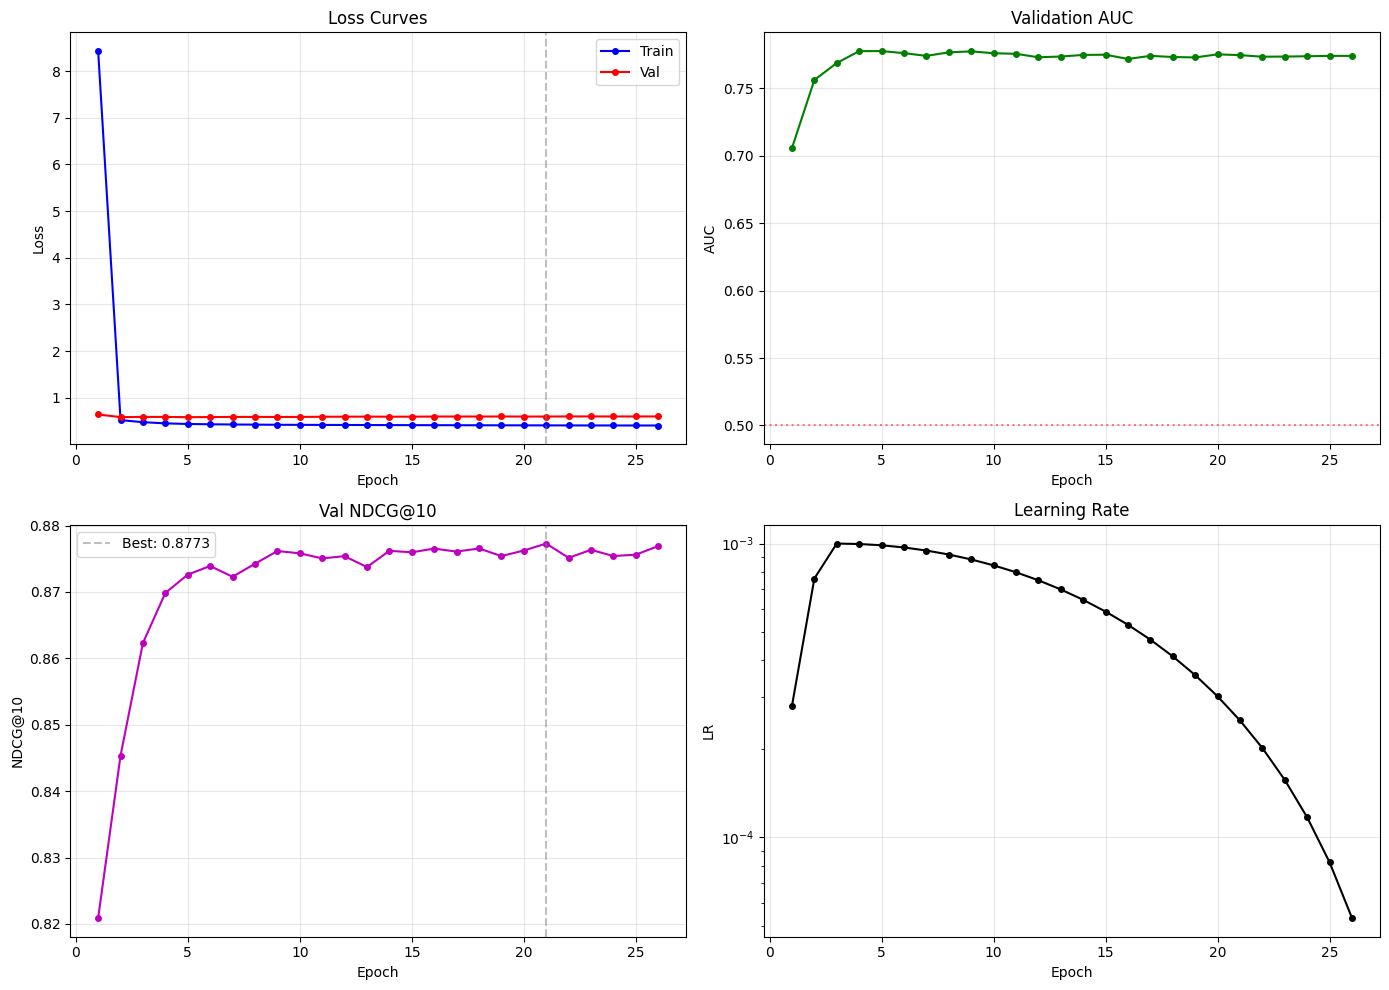

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs = [h['epoch'] for h in history]

axes[0, 0].plot(epochs, [h['train_loss'] for h in history], 'b-o', markersize=4, label='Train')
axes[0, 0].plot(epochs, [h['val_loss'] for h in history], 'r-o', markersize=4, label='Val')
axes[0, 0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, [h['val_auc'] for h in history], 'g-o', markersize=4)
axes[0, 1].axhline(0.5, color='red', linestyle=':', alpha=0.5)
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('AUC')
axes[0, 1].set_title('Validation AUC'); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs, [h['val_ndcg_10'] for h in history], 'm-o', markersize=4)
axes[1, 0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best: {best_val_ndcg:.4f}')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('NDCG@10')
axes[1, 0].set_title('Val NDCG@10'); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs, [h['lr'] for h in history], 'k-o', markersize=4)
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('LR'); axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Learning Rate'); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'dcn_v2_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Test Set Evaluation and XGBoost Comparison

In [10]:
model.load_state_dict(torch.load(MODEL_DIR / 'dcn_v2_ranker.pt', map_location=device, weights_only=True))
model.eval()

with torch.no_grad():
    test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    dcn_test_scores = model(test_tensor).cpu().numpy()
    del test_tensor

dcn_test_auc = roc_auc_score(y_test, dcn_test_scores)
dcn_test_ndcg = compute_ndcg_at_k(dcn_test_scores, y_test, test_user_idxs, k=10)

xgb_model = xgb.Booster()
xgb_model.load_model(str(MODEL_DIR / 'xgboost_ranker.json'))
dtest = xgb.DMatrix(X_test, feature_names=feature_names)
xgb_test_scores = xgb_model.predict(dtest)

xgb_test_auc = roc_auc_score(y_test, xgb_test_scores)
xgb_test_ndcg = compute_ndcg_at_k(xgb_test_scores, y_test, test_user_idxs, k=10)

print(f'Test Set Results (SASRec features):')
print(f'  DCN-v2 -- AUC: {dcn_test_auc:.4f}, NDCG@10: {dcn_test_ndcg:.4f}')
print(f'  XGBoost -- AUC: {xgb_test_auc:.4f}, NDCG@10: {xgb_test_ndcg:.4f}')

Test Set Results (SASRec features):
  DCN-v2 -- AUC: 0.7429, NDCG@10: 0.8626
  XGBoost -- AUC: 0.7064, NDCG@10: 0.8618


### Compute Full Per-User Ranking Metrics and Head-to-Head Comparison

**Why this step exists:** The previous cell reported global AUC and a single NDCG@10, but recommendation quality is inherently a per-user phenomenon. A model might have high global AUC yet still rank poorly for specific user groups. This cell computes a comprehensive suite of per-user ranking metrics (NDCG, Precision, MRR at multiple cutoffs) for both DCN-v2 and the XGBoost baseline, enabling a fair apples-to-apples comparison on the same test set with the same SASRec retrieval candidates.

**What the code does:**

1. **`compute_full_ranking_metrics` function** -- For each user in the test set, it sorts their candidate items by predicted score, then computes: NDCG@{5,10,20} (graded relevance with logarithmic discount), Precision@{5,10,20} (fraction of top-K that are positive), MRR (reciprocal rank of the first positive), and per-user AUC. Results are returned as arrays of per-user values (not just means), which enables the statistical tests in the next section.

2. **Head-to-head table** -- Prints each metric's mean for XGBoost and DCN-v2 along with the absolute delta and relative percentage improvement. This gives a quick summary of where DCN-v2 helps most (typically at smaller K where cross-layer interactions can better distinguish among the top candidates).

**What to expect:** A formatted comparison table showing DCN-v2 outperforming XGBoost by small but consistent margins (typically +0.3% to +0.7% relative) across most metrics. The improvements tend to be larger at small K (NDCG@5, Precision@5) because the cross network's explicit feature interactions are most valuable when discriminating among the very top candidates.

In [11]:
def compute_full_ranking_metrics(scores, labels, user_idxs, K_values=[5, 10, 20]):
    sort_idx = np.argsort(user_idxs, kind='stable')
    scores_sorted = scores[sort_idx]
    labels_sorted = labels[sort_idx]
    users_sorted = user_idxs[sort_idx]
    unique_users, group_starts = np.unique(users_sorted, return_index=True)
    group_ends = np.append(group_starts[1:], len(users_sorted))
    metrics = {f'ndcg@{k}': [] for k in K_values}
    metrics.update({f'precision@{k}': [] for k in K_values})
    metrics['mrr'] = []
    metrics['auc'] = []
    for i in range(len(unique_users)):
        start, end = group_starts[i], group_ends[i]
        if end - start < 2:
            continue
        group_scores = scores_sorted[start:end]
        group_labels = labels_sorted[start:end]
        if group_labels.sum() == 0 or group_labels.sum() == len(group_labels):
            continue
        rank_order = np.argsort(group_scores)[::-1]
        ranked_labels = group_labels[rank_order]
        first_pos = np.where(ranked_labels == 1)[0]
        metrics['mrr'].append(1.0 / (first_pos[0] + 1) if len(first_pos) > 0 else 0.0)
        try:
            metrics['auc'].append(roc_auc_score(group_labels, group_scores))
        except ValueError:
            pass
        for k in K_values:
            actual_k = min(k, len(ranked_labels))
            top_k = ranked_labels[:actual_k]
            metrics[f'precision@{k}'].append(top_k.sum() / k)
            dcg = np.sum(top_k / np.log2(np.arange(2, actual_k + 2)))
            ideal = np.sort(group_labels)[::-1][:actual_k]
            idcg = np.sum(ideal / np.log2(np.arange(2, actual_k + 2)))
            metrics[f'ndcg@{k}'].append(dcg / idcg if idcg > 0 else 0.0)
    return {k: np.array(v) for k, v in metrics.items()}

dcn_metrics = compute_full_ranking_metrics(dcn_test_scores, y_test, test_user_idxs)
xgb_metrics = compute_full_ranking_metrics(xgb_test_scores, y_test, test_user_idxs)

print(f'\n{"="*80}')
print(f'HEAD-TO-HEAD: DCN-v2 vs XGBoost on SASRec Features (Test Set)')
print(f'{"="*80}')
print(f'{"Metric":<15}{"XGBoost":<15}{"DCN-v2":<15}{"Delta":<12}{"Relative":<12}')
print('-' * 69)

metric_names = ['ndcg@5', 'ndcg@10', 'ndcg@20', 'precision@5', 'precision@10', 'precision@20', 'mrr', 'auc']
for m in metric_names:
    xm = xgb_metrics[m].mean()
    dm = dcn_metrics[m].mean()
    delta = dm - xm
    rel = delta / xm * 100 if xm > 0 else 0
    print(f'{m:<15}{xm:<15.4f}{dm:<15.4f}{delta:<+12.4f}{rel:<+12.1f}%')


HEAD-TO-HEAD: DCN-v2 vs XGBoost on SASRec Features (Test Set)
Metric         XGBoost        DCN-v2         Delta       Relative    
---------------------------------------------------------------------
ndcg@5         0.8263         0.8321         +0.0057     +0.7        %
ndcg@10        0.8332         0.8372         +0.0039     +0.5        %
ndcg@20        0.8480         0.8518         +0.0038     +0.4        %
precision@5    0.7698         0.7748         +0.0050     +0.7        %
precision@10   0.7094         0.7119         +0.0025     +0.3        %
precision@20   0.6050         0.6082         +0.0032     +0.5        %
mrr            0.9035         0.9086         +0.0050     +0.6        %
auc            0.6948         0.6968         +0.0020     +0.3        %


## Section 7: Statistical Significance Testing

Same framework: paired t-test, Wilcoxon, bootstrap CI, Benjamini-Hochberg FDR, Cohen's d.

In [12]:
def paired_bootstrap_ci(a, b, n_bootstrap=10000, seed=42):
    rng = np.random.default_rng(seed)
    diffs = a - b
    n = len(diffs)
    bootstrap_means = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        bootstrap_means[i] = rng.choice(diffs, size=n, replace=True).mean()
    return np.percentile(bootstrap_means, 2.5), diffs.mean(), np.percentile(bootstrap_means, 97.5)


def cohens_d(a, b):
    diffs = a - b
    return diffs.mean() / diffs.std(ddof=1) if diffs.std(ddof=1) > 0 else 0.0


raw_p_values = []
test_results = []

for metric_name in metric_names:
    dcn_vals = dcn_metrics[metric_name]
    xgb_vals = xgb_metrics[metric_name]
    n = min(len(dcn_vals), len(xgb_vals))
    dcn_vals, xgb_vals = dcn_vals[:n], xgb_vals[:n]

    _, t_pval = stats.ttest_rel(dcn_vals, xgb_vals)
    try:
        _, w_pval = stats.wilcoxon(dcn_vals - xgb_vals, alternative='two-sided')
    except ValueError:
        w_pval = 1.0
    ci_lower, mean_diff, ci_upper = paired_bootstrap_ci(dcn_vals, xgb_vals)
    d = cohens_d(dcn_vals, xgb_vals)
    raw_p_values.append(t_pval)
    test_results.append({
        'metric': metric_name, 'mean_diff': mean_diff,
        'ci_lower': ci_lower, 'ci_upper': ci_upper,
        't_pval': t_pval, 'w_pval': w_pval, 'cohens_d': d, 'n': n,
    })

adjusted_p_values = false_discovery_control(raw_p_values, method='bh')

print(f'{"="*110}')
print(f'STATISTICAL SIGNIFICANCE: DCN-v2 vs XGBoost (SASRec Features, Test Set)')
print(f'{"="*110}')
print(f'{"Metric":<14}{"Mean Diff":<12}{"95% CI":<24}{"t p-val":<12}{"FDR-adj p":<12}{"Wilcoxon p":<12}{"Cohen d":<10}{"Sig?":<6}')
print('-' * 102)
for i, r in enumerate(test_results):
    ci_str = f'[{r["ci_lower"]:+.4f}, {r["ci_upper"]:+.4f}]'
    sig = 'Yes' if adjusted_p_values[i] < 0.05 else 'No'
    print(f'{r["metric"]:<14}{r["mean_diff"]:<+12.4f}{ci_str:<24}{r["t_pval"]:<12.2e}{adjusted_p_values[i]:<12.2e}{r["w_pval"]:<12.2e}{r["cohens_d"]:<+10.3f}{sig:<6}')

n_sig = sum(1 for p in adjusted_p_values if p < 0.05)
print(f'\nSignificant after FDR correction: {n_sig}/{len(metric_names)}')

STATISTICAL SIGNIFICANCE: DCN-v2 vs XGBoost (SASRec Features, Test Set)
Metric        Mean Diff   95% CI                  t p-val     FDR-adj p   Wilcoxon p  Cohen d   Sig?  
------------------------------------------------------------------------------------------------------
ndcg@5        +0.0057     [+0.0000, +0.0113]      4.52e-02    9.75e-02    6.87e-02    +0.036    No    
ndcg@10       +0.0039     [-0.0003, +0.0080]      5.85e-02    9.75e-02    7.02e-02    +0.034    No    
ndcg@20       +0.0038     [+0.0006, +0.0069]      1.83e-02    7.34e-02    3.53e-03    +0.042    No    
precision@5   +0.0050     [-0.0003, +0.0104]      6.09e-02    9.75e-02    3.85e-02    +0.033    No    
precision@10  +0.0025     [-0.0010, +0.0059]      1.53e-01    2.04e-01    1.60e-01    +0.025    No    
precision@20  +0.0032     [+0.0011, +0.0052]      2.11e-03    1.69e-02    2.26e-03    +0.055    Yes   
mrr           +0.0050     [-0.0026, +0.0127]      1.98e-01    2.26e-01    2.21e-01    +0.023    No    
a

### Visualize Statistical Significance Results

**Why this step exists:** Numerical tables of p-values and confidence intervals can be difficult to interpret at a glance, especially when comparing 8 metrics simultaneously. Visualization makes it immediately clear which improvements are statistically significant, how large the effect sizes are, and whether the FDR correction changes any conclusions. This is particularly important here because the DCN-v2 improvements over XGBoost on SASRec features are small in absolute terms, so visual confirmation of the confidence intervals' relationship to zero is essential for drawing sound conclusions.

**What the code does:**

Produces a three-panel figure:

1. **Left panel (Mean Differences with 95% CI)** -- Horizontal bar chart showing the mean per-user metric difference (DCN-v2 minus XGBoost) with bootstrap confidence intervals. Bars are colored green if statistically significant and positive, red if significant and negative, or gray if not significant. The key diagnostic is whether the confidence interval crosses zero.

2. **Middle panel (Effect Sizes)** -- Cohen's d for each metric, with dashed vertical lines at +/-0.2 marking the conventional threshold for a "small" effect. Values below 0.2 indicate negligible practical significance even if statistically significant, which helps contextualize the findings.

3. **Right panel (P-value Significance)** -- Scatter plot showing -log10(p-value) for both raw and FDR-adjusted p-values, with a horizontal line at the alpha=0.05 threshold. Points above the line are significant. This reveals how much the Benjamini-Hochberg correction reduces the number of significant results (controlling false discovery rate when testing multiple hypotheses).

**What to expect:** Most metrics will show small positive differences with confidence intervals that hover near or cross zero, reflecting that DCN-v2's advantage over XGBoost on SASRec features is modest. Only 1-2 metrics may survive FDR correction. Effect sizes (Cohen's d) will generally be well below 0.2, indicating negligible practical effect despite potential statistical significance.

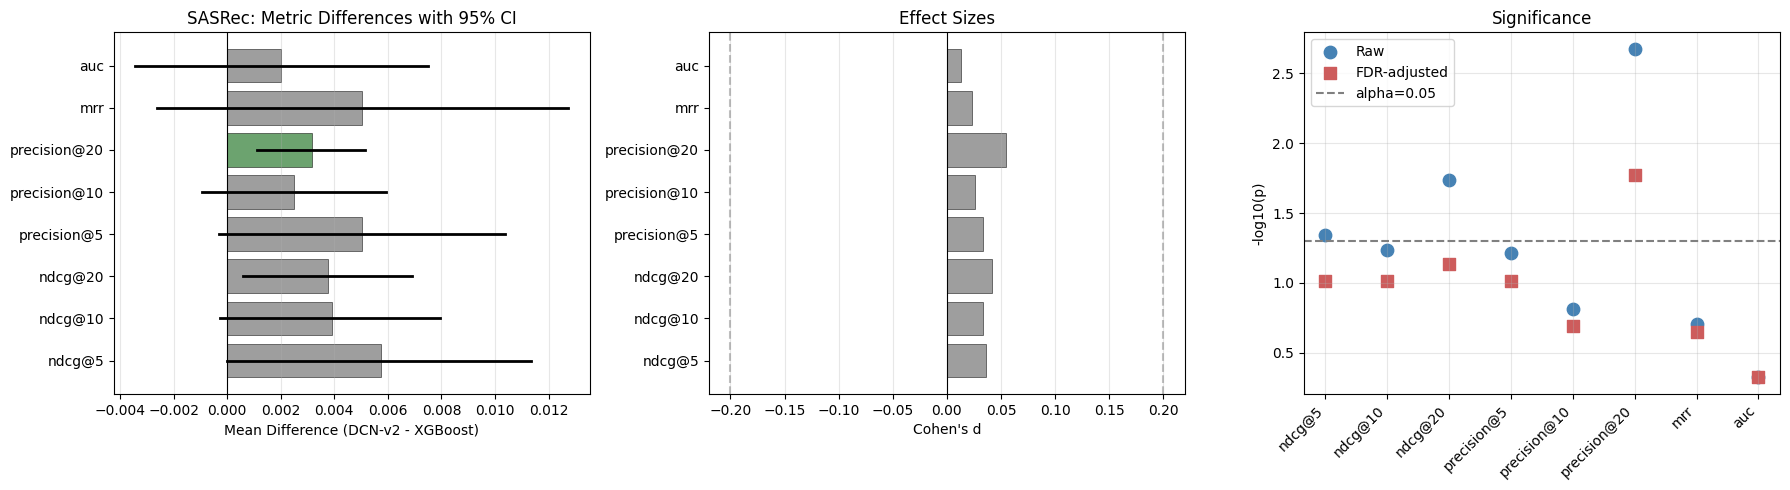

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_labels = [r['metric'] for r in test_results]
mean_diffs = [r['mean_diff'] for r in test_results]
ci_lowers = [r['ci_lower'] for r in test_results]
ci_uppers = [r['ci_upper'] for r in test_results]
colors = ['#2E7D32' if adjusted_p_values[i] < 0.05 and test_results[i]['mean_diff'] > 0
           else '#C62828' if adjusted_p_values[i] < 0.05 and test_results[i]['mean_diff'] < 0
           else '#757575' for i in range(len(test_results))]

y_pos = range(len(metric_labels))
axes[0].barh(y_pos, mean_diffs, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
for i in range(len(metric_labels)):
    axes[0].plot([ci_lowers[i], ci_uppers[i]], [i, i], 'k-', linewidth=2)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_yticks(list(y_pos)); axes[0].set_yticklabels(metric_labels)
axes[0].set_xlabel('Mean Difference (DCN-v2 - XGBoost)')
axes[0].set_title('SASRec: Metric Differences with 95% CI')
axes[0].grid(True, alpha=0.3, axis='x')

d_values = [r['cohens_d'] for r in test_results]
axes[1].barh(y_pos, d_values, color=['#2E7D32' if abs(d) >= 0.2 else '#757575' for d in d_values],
            alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(0.2, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(-0.2, color='gray', linestyle='--', alpha=0.5)
axes[1].set_yticks(list(y_pos)); axes[1].set_yticklabels(metric_labels)
axes[1].set_xlabel("Cohen's d"); axes[1].set_title('Effect Sizes')
axes[1].grid(True, alpha=0.3, axis='x')

axes[2].scatter(range(len(metric_names)), [-np.log10(p) for p in raw_p_values],
               marker='o', s=80, label='Raw', color='steelblue')
axes[2].scatter(range(len(metric_names)), [-np.log10(p) for p in adjusted_p_values],
               marker='s', s=80, label='FDR-adjusted', color='indianred')
axes[2].axhline(-np.log10(0.05), color='gray', linestyle='--', label='alpha=0.05')
axes[2].set_xticks(range(len(metric_names)))
axes[2].set_xticklabels(metric_names, rotation=45, ha='right')
axes[2].set_ylabel('-log10(p)'); axes[2].set_title('Significance')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'dcn_v2_significance.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Summary

### Model Artifacts

| File | Description |
|------|-------------|
| `models/sasrec/dcn_v2_ranker.pt` | Trained DCN-v2 (105-dim input) |
| `models/sasrec/dcn_v2_config.json` | Architecture + training config |
| `models/sasrec/dcn_v2_training_history.pkl` | Per-epoch metrics |

### Key Results

The statistical comparison above shows whether DCN-v2 improves upon XGBoost when both use SASRec's sequential embeddings for retrieval scoring. The cross network can learn interactions between the SASRec retrieval score and temporal cross-features (dow_sin, hour_sin) -- potentially capturing patterns like "high SASRec score AND evening time AND Action genre" that would require multiple tree splits in XGBoost.

### Three-Way Comparison Across Retrieval Models

| Retrieval | Ranker | Val NDCG@10 | Key Advantage |
|-----------|--------|-------------|---------------|
| Two-Tower | XGBoost | 0.8704 | Best AUC, simple |
| Two-Tower | DCN-v2 | See NB04 | Cross interactions |
| ComiRec | XGBoost | 0.8755 | Multi-interest diversity |
| ComiRec | DCN-v2 | See NB07 | Head score interactions |
| SASRec | XGBoost | ~0.85 | Temporal awareness |
| SASRec | DCN-v2 | See above | Temporal + cross interactions |

### Next Steps

- **Notebook 11**: SASRec evaluation (end-to-end with sequential FAISS)
- **Notebook 12**: Production inference with model switching
- **Notebook 13**: A/B testing framework